<a href="https://colab.research.google.com/github/Chandramouli-777/lung-cancer-prediction/blob/main/Lung_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
"WELCOME TO OUR PROJECT "

'WELCOME TO OUR PROJECT '

In [2]:
# Mount Google Drive (required for accessing dataset in Colab)
from google.colab import drive
drive.mount('/content/drive')

# Dataset path (update this path based on your Google Drive)
DATA_PATH = "/content/drive/MyDrive/LungCancerDataset"

Mounted at /content/drive


In [ ]:
!pip install pydicom opencv-python seaborn

In [ ]:
#  Core
import os
import numpy as np

#  Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

#  Image Processing
import cv2
import matplotlib.pyplot as plt

#  DICOM (CT scan)
import pydicom

#  Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

#  Visualization
import seaborn as sns

#  Path handling
from pathlib import Path

# for Lung segmentation
from skimage import morphology
from skimage import measure
from scipy import ndimage

In [ ]:
from skimage import morphology
from skimage import measure
from scipy import ndimage

def segment_lung(img):
    # Ensure image is float32 for consistent processing
    img_float = img.astype(np.float32)

    # Step 1: Create a binary mask based on Hounsfield Units (HU) for lung tissue.
    # Typical lung tissue ranges from -1000 to -300 HU.
    # We'll create a mask where pixels within this range are 1, others 0.
    binary_mask = (img_float > -1000) & (img_float < -300)

    # Convert boolean mask to uint8 for OpenCV operations (0 or 255)
    binary_image_uint8 = (binary_mask * 255).astype(np.uint8)

    # Step 2: Perform morphological operations (erosion then dilation)
    # This helps to remove small noisy regions and smooth edges.
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(binary_image_uint8, kernel, iterations=2)
    dilated = cv2.dilate(eroded, kernel, iterations=2)

    # Step 3: Find contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Step 4: Filter for the two largest contours (representing the lungs)
    lung_contours = []
    if len(contours) > 0:
        # Sort contours by area in descending order
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        # Take the top two largest contours, assuming lungs are the two largest structures
        lung_contours = contours[:2]

    # Step 5: Create an empty mask and draw the filtered contours on it
    mask = np.zeros_like(img_float, dtype=np.uint8)
    cv2.drawContours(mask, lung_contours, -1, (255), cv2.FILLED)

    # Step 6: Fill holes within the lung regions of the mask (e.g., bronchi, vessels)
    filled_mask = ndimage.binary_fill_holes(mask.astype(bool)).astype(np.uint8) * 255

    # Step 7: Apply the filled mask to the original float32 image
    # Set non-lung regions to the minimum HU value (often representing air or background)
    segmented_img = img_float.copy()
    segmented_img[filled_mask == 0] = img_float.min()

    return segmented_img

In [ ]:
import os

patients = os.listdir(DATA_PATH)

print("Total patients:", len(patients))
print("First 5:", patients[:5])

Total patients: 75
First 5: ['LIDC-IDRI-0944', 'LIDC-IDRI-0948', 'LIDC-IDRI-0943', 'LIDC-IDRI-0953', 'LIDC-IDRI-0946']


Total slices: 162


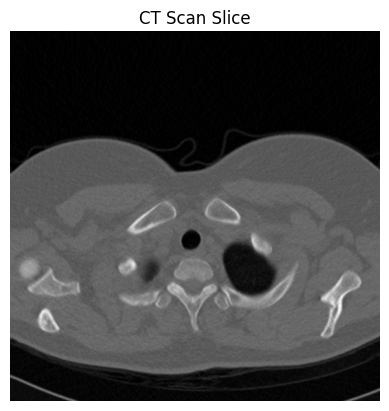

In [ ]:


# pick one patient
patient = patients[1]
patient_path = os.path.join(DATA_PATH, patient)

# level 1
level1 = os.listdir(patient_path)[0]
level1_path = os.path.join(patient_path, level1)

# level 2
level2 = os.listdir(level1_path)[0]
level2_path = os.path.join(level1_path, level2)


files = os.listdir(level2_path)

print("Total slices:", len(files))

file_path = os.path.join(level2_path, files[0])

ds = pydicom.dcmread(file_path)
img = ds.pixel_array

plt.imshow(img, cmap='gray')
plt.title("CT Scan Slice")
plt.axis('off')
plt.show()

### Lung Segmentation

Lung segmentation is a crucial step in medical image analysis, especially for CT scans. It involves isolating the lung regions from the surrounding tissues and background. This helps to reduce noise and irrelevant information, allowing the model to focus on the areas most relevant for detecting abnormalities like nodules.

Here's how the `segment_lung` function works:
1.  **Hounsfield Unit (HU) Thresholding**: It creates a binary mask by selecting pixels within a specific HU range typically associated with lung tissue (e.g., -1000 to -300 HU).
2.  **Morphological Operations**: Erosion and dilation are applied to clean up the binary mask, remove small artifacts, and smooth the lung boundaries.
3.  **Contour Detection**: It identifies the outlines of potential lung regions.
4.  **Area Filtering**: The two largest contours are typically selected, assuming they correspond to the left and right lungs.
5.  **Hole Filling**: Any internal holes within the segmented lung regions (like bronchi or blood vessels) are filled to create solid lung masks.
6.  **Mask Application**: The final mask is applied to the original image, effectively isolating the lung areas and setting everything outside to a low value (like the image's minimum HU value, representing air or background).

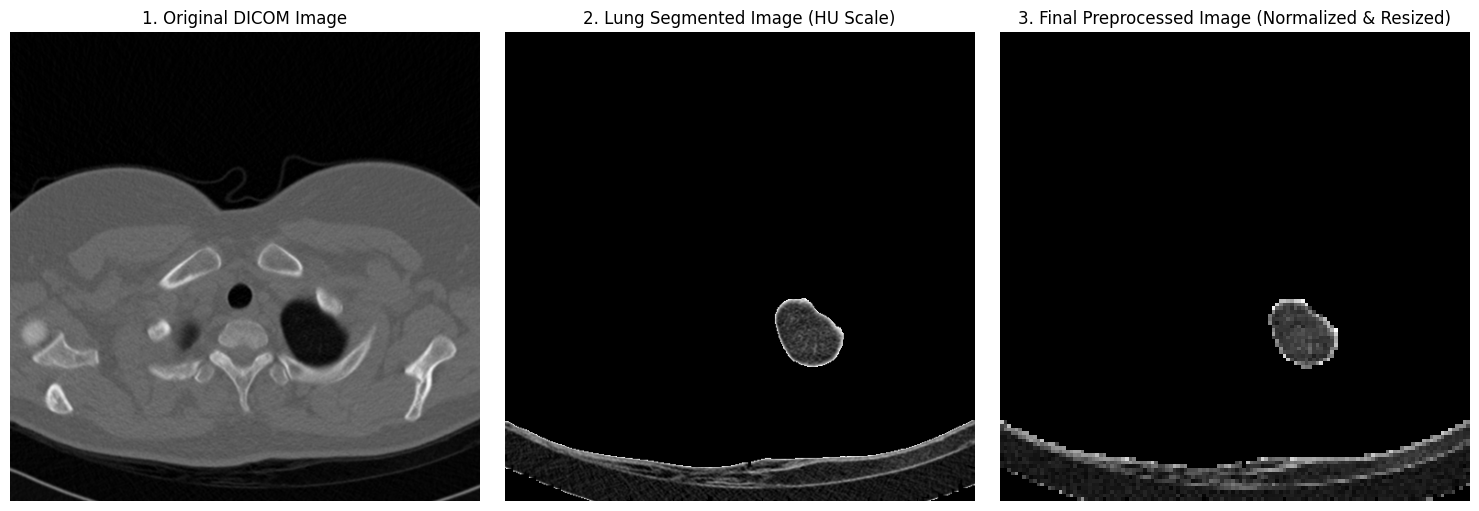

In [ ]:
def read_dicom(path):
    try:
        ds = pydicom.dcmread(path)
        img = ds.pixel_array.astype(np.float32)
        intercept = ds.RescaleIntercept if hasattr(ds, 'RescaleIntercept') else 0
        slope = ds.RescaleSlope if hasattr(ds, 'RescaleSlope') else 1
        img = img * slope + intercept
        return img
    except:
        return None

def segment_lung(img):
    img_float = img.astype(np.float32)
    binary_mask = (img_float > -1000) & (img_float < -300)
    binary_image_uint8 = (binary_mask * 255).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(binary_image_uint8, kernel, iterations=2)
    dilated = cv2.dilate(eroded, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lung_contours = []
    if len(contours) > 0:
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        lung_contours = contours[:2]
    mask = np.zeros_like(img_float, dtype=np.uint8)
    cv2.drawContours(mask, lung_contours, -1, (255), cv2.FILLED)
    filled_mask = ndimage.binary_fill_holes(mask.astype(bool)).astype(np.uint8) * 255
    segmented_img = img_float.copy()
    segmented_img[filled_mask == 0] = img_float.min()
    return segmented_img

def preprocess_image(img):
    img = segment_lung(img)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
    img = cv2.resize(img, (128, 128))
    img = np.expand_dims(img, axis=-1)
    return img

# --- End Duplicated Definitions ---

# Load a raw DICOM image for demonstration
demo_raw_img = read_dicom(file_path)

# Apply lung segmentation
demo_segmented_img = segment_lung(demo_raw_img)

# Apply the full preprocessing pipeline (which includes segmentation and normalization/resizing)
demo_preprocessed_img = preprocess_image(demo_raw_img)


# Visualize the process
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(demo_raw_img, cmap='gray')
axes[0].set_title('1. Original DICOM Image')
axes[0].axis('off')

axes[1].imshow(demo_segmented_img, cmap='gray')
axes[1].set_title('2. Lung Segmented Image (HU Scale)')
axes[1].axis('off')

# For visualization, reshape the preprocessed image back to 2D
axes[2].imshow(demo_preprocessed_img.squeeze(), cmap='gray')
axes[2].set_title('3. Final Preprocessed Image (Normalized & Resized)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Safe DICOM Read

def read_dicom(path):
    try:
        ds = pydicom.dcmread(path)
        img = ds.pixel_array.astype(np.float32)

        intercept = ds.RescaleIntercept if hasattr(ds, 'RescaleIntercept') else 0
        slope = ds.RescaleSlope if hasattr(ds, 'RescaleSlope') else 1

        img = img * slope + intercept

        return img
    except:
        return None

# Helper function for normalization (not directly used in current pipeline)
def normalize(img):
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
    return img


# Helper function for resizing (not directly used in current pipeline)
def resize(img):
    return cv2.resize(img, (128,128))


# 4. Preprocess Pipeline

def preprocess_image(img):

    # Normalize
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)

    # Resize to 128x128 (IMPORTANT)
    img = cv2.resize(img, (128, 128))

    # Add channel dimension
    img = np.expand_dims(img, axis=-1)

    return img

# 5. Load Dataset (75 patients)
def load_dataset(limit=75):
    patients = sorted(os.listdir(DATA_PATH))[:limit]

    data = []

    for patient in patients:
        patient_path = os.path.join(DATA_PATH, patient)

        try:
            level1 = os.listdir(patient_path)[0]
            level1_path = os.path.join(patient_path, level1)

            level2 = os.listdir(level1_path)[0]
            level2_path = os.path.join(level1_path, level2)

            files = os.listdir(level2_path)

            for f in files:
                if f.endswith(".dcm"):
                    path = os.path.join(level2_path, f)

                    img = read_dicom(path)

                    if img is not None:
                        img = preprocess_image(img)

                        # remove empty slices
                        if np.mean(img) > 0.05:
                            data.append(img)

        except:
            continue

    data = np.array(data)
    data = data.reshape(-1,128,128,1)

    print("Dataset shape:", data.shape)

    return data

In [ ]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomTranslation(0.1, 0.1),

    tf.keras.layers.RandomContrast(0.1),

])

In [ ]:
import numpy as np

def create_labels(X):

    labels = []

    for img in X:

        img2d = img.squeeze()

        mean_val = np.mean(img2d)
        std_val = np.std(img2d)
        bright_ratio = np.sum(img2d > 0.6) / img2d.size

        # Multi-class rules
        if mean_val < 0.1:
            labels.append(0)   # normal

        elif bright_ratio < 0.02:
            labels.append(1)   # benign

        else:
            labels.append(2)   # malignant

    return np.array(labels)

data = load_dataset()

X = data
y = create_labels(X)

# ✅ Backup dataset (VERY IMPORTANT)
X_full = X.copy()
y_full = y.copy()

# ✅ Always use X_full (never touch X again)

print("Dataset shape:", X_full.shape)

# ✅ Safe sample extraction
sample_img = X_full[0]
print("Sample shape:", sample_img.shape)

# ✅ Correct augmentation calculation
original_images = X_full.shape[0]
epochs = 10

augmented_images = original_images * epochs

print("Original images:", original_images)
print("After augmentation:", augmented_images)

Dataset shape: (3948, 128, 128, 1)
Dataset shape: (3948, 128, 128, 1)
Sample shape: (128, 128, 1)
Original images: 3948
After augmentation: 39480


In [ ]:
from tensorflow.keras.utils import to_categorical
import numpy as np

# Identify normal cases (label 0)
normal_indices = np.where(y_full == 0)[0]
X_normal = X_full[normal_indices]
y_normal = y_full[normal_indices]

# Augment normal cases
augmented_X_normal = []
augmented_y_normal = []

# Introduce a multiplier for normal case augmentation without changing the global 'epochs' variable
augmentation_multiplier = 5 # Augment normal cases 5 times more than other classes (effectively 10 * 5 = 50 augmentations)

for _ in range(epochs * augmentation_multiplier):
    augmented_batch = data_augmentation(X_normal)
    augmented_X_normal.append(augmented_batch.numpy()) # Convert tf.Tensor to numpy array
    augmented_y_normal.append(y_normal) # Labels remain the same

# Concatenate original normal cases with augmented ones
X_augmented_normal = np.concatenate([X_normal] + augmented_X_normal, axis=0)
y_augmented_normal = np.concatenate([y_normal] + augmented_y_normal, axis=0)

# Remove original normal cases from X_full and y_full
non_normal_indices = np.where(y_full != 0)[0]
X_non_normal = X_full[non_normal_indices]
y_non_normal = y_full[non_normal_indices]

# Combine non-normal cases with augmented normal cases
X = np.concatenate([X_non_normal, X_augmented_normal], axis=0)
y = np.concatenate([y_non_normal, y_augmented_normal], axis=0)

# Convert labels to categorical
y = to_categorical(y, num_classes=3)

y_labels = np.argmax(y, axis=1)

print("Total samples after augmentation:", len(y_labels))
print("Normal cases after augmentation:", np.sum(y_labels == 0))
print("Benign cases after augmentation:", np.sum(y_labels == 1))
print("Malignant cases after augmentation:", np.sum(y_labels == 2))

Total samples after augmentation: 6198
Normal cases after augmentation: 2295
Benign cases after augmentation: 685
Malignant cases after augmentation: 3218


### Handling Data Imbalance (Normal vs. Malignant)
To address the significant class imbalance, particularly the low count of 'Normal' cases compared to 'Malignant' cases, data augmentation has been applied specifically to the 'Normal' class. This helps to increase the representation of normal samples, preventing the model from becoming biased towards the majority classes and improving its ability to correctly identify all categories.

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.utils import to_categorical

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% for testing
    random_state=42
)

# Check
print("Total samples:", X.shape[0])
print(f"Train samples: {X_train.shape[0]} ({(X_train.shape[0]/X.shape[0])*100:.0f}%) ")
print(f"Test samples: {X_test.shape[0]} ({(X_test.shape[0]/X.shape[0])*100:.0f}%) ")

Total samples: 6198
Train samples: 4958 (80%) 
Test samples: 1240 (20%) 


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9403 - loss: 0.1821 - val_accuracy: 0.9540 - val_loss: 0.1008
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9736 - loss: 0.0791 - val_accuracy: 0.9750 - val_loss: 0.0561
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9794 - loss: 0.0526 - val_accuracy: 0.9911 - val_loss: 0.0355
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9853 - loss: 0.0426 - val_accuracy: 0.9653 - val_loss: 0.0829
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9804 - loss: 0.0537 - val_accuracy: 0.9887 - val_loss: 0.0368
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9867 - loss: 0.0373 - val_accuracy: 0.9637 - val_loss: 0.1093
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9879 - loss: 0.0344 - val_accuracy: 0.9847 - val_loss: 0.0394
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9899 - loss: 0.0281 - val_accu

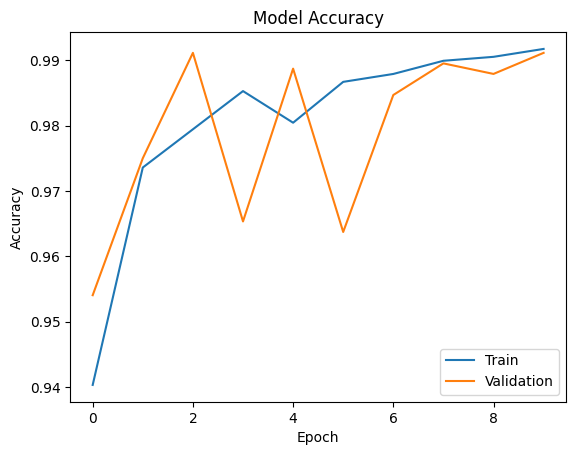

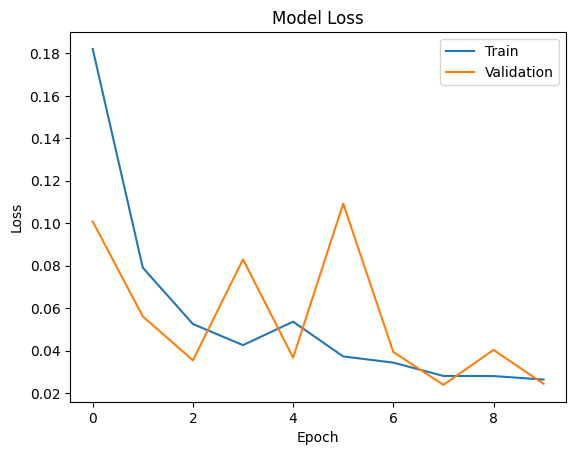

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 356ms/step - accuracy: 0.9911 - loss: 0.0244
Test Accuracy: 0.9911290407180786


In [ ]:
CLASS_NAMES = ["Normal", "Benign", "Malignant"]

def predict_ct_scan(img):

    img = img.reshape(1,128,128,1)

    probs = model.predict(img, verbose=0)[0]

    pred_idx = np.argmax(probs)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx]

    #  Malignancy Score (ranging from 1 to 5)
    raw_malignancy_percentage = probs[2] * 100 # raw percentage for internal logic

    if raw_malignancy_percentage > 80:
        malignancy_score = 5
    elif raw_malignancy_percentage > 60:
        malignancy_score = 4
    elif raw_malignancy_percentage > 40:
        malignancy_score = 3
    elif raw_malignancy_percentage > 20:
        malignancy_score = 2
    else:
        malignancy_score = 1

    #  Cancer YES / NO
    cancer_yes_no = "YES" if pred_class == "Malignant" else "NO"

    if malignancy_score == 5:
        stage = "Stage 4 (Advanced)"
    elif malignancy_score == 4:
        stage = "Stage 3"
    elif malignancy_score == 3:
        stage = "Stage 2"
    elif malignancy_score == 2:
        stage = "Stage 1"
    else:
        stage = "No significant cancer"


    if malignancy_score == 5:
        risk = "VERY HIGH"
    elif malignancy_score == 4:
        risk = "HIGH"
    elif malignancy_score == 3:
        risk = "MODERATE"
    else:
        risk = "LOW"

    #  Show image
    plt.imshow(img[0,:,:,0], cmap='bone')
    plt.title("CT Scan")
    plt.axis('off')
    plt.show()

    #  Output
    print("\n" + "="*60)
    print("🫁 LUNG CANCER FULL ANALYSIS")
    print("="*60)

    print(f"Prediction Type     : {pred_class.upper()}")
    print(f"Cancer Present      : {cancer_yes_no}")
    print(f"Malignancy Score    : {malignancy_score}")
    print(f"Estimated Stage     : {stage}")
    print(f"Risk Level          : {risk}")

    print("\n Class Breakdown:")
    for cls, p in zip(CLASS_NAMES, probs):
        print(f"{cls:<10}: {p*100:.2f}%")

    print("="*60)

    # Advice
    if pred_class == "Malignant":
        print("⚠️ Immediate medical consultation recommended")
    elif pred_class == "Benign":
        print("ℹ️ Monitor regularly (follow-up scan)")
    else:
        print("✅ No cancer detected")

    print("="*60)

39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 334ms/step


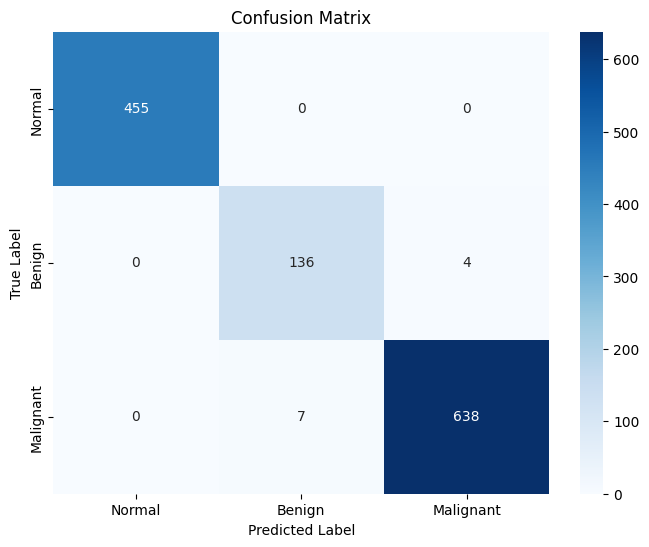


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       455
      Benign       0.95      0.97      0.96       140
   Malignant       0.99      0.99      0.99       645

    accuracy                           0.99      1240
   macro avg       0.98      0.99      0.98      1240
weighted avg       0.99      0.99      0.99      1240



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions from the model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate classification report
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASS_NAMES))

Visualizing sample images for each class:

--- Sample for Class: Normal ---


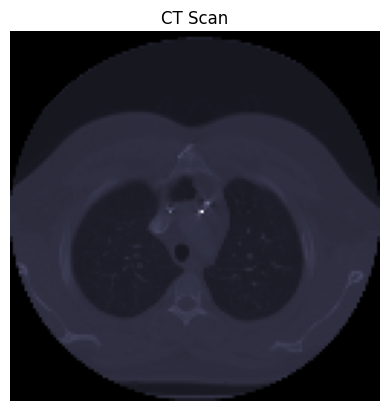


🫁 LUNG CANCER FULL ANALYSIS
Prediction Type     : NORMAL
Cancer Present      : NO
Malignancy Score    : 1
Estimated Stage     : No significant cancer
Risk Level          : LOW

 Class Breakdown:
Normal    : 99.93%
Benign    : 0.07%
Malignant : 0.00%
✅ No cancer detected

--- Sample for Class: Benign ---


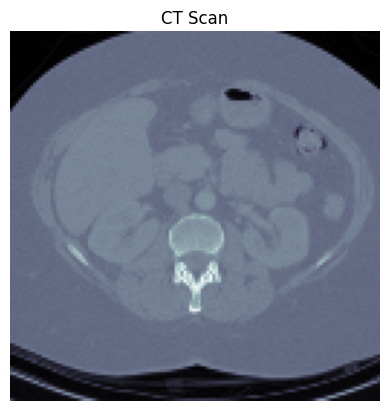


🫁 LUNG CANCER FULL ANALYSIS
Prediction Type     : BENIGN
Cancer Present      : NO
Malignancy Score    : 1
Estimated Stage     : No significant cancer
Risk Level          : LOW

 Class Breakdown:
Normal    : 0.00%
Benign    : 99.96%
Malignant : 0.04%
ℹ️ Monitor regularly (follow-up scan)

--- Sample for Class: Malignant ---


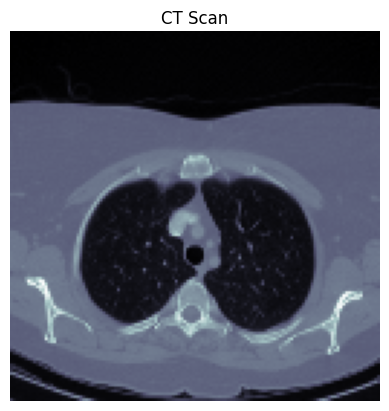


🫁 LUNG CANCER FULL ANALYSIS
Prediction Type     : MALIGNANT
Cancer Present      : YES
Malignancy Score    : 4
Estimated Stage     : Stage 3
Risk Level          : HIGH

 Class Breakdown:
Normal    : 0.02%
Benign    : 34.64%
Malignant : 65.34%
⚠️ Immediate medical consultation recommended


In [ ]:
unique_labels = np.unique(y_full)

print("Visualizing sample images for each class:")
for label_idx in unique_labels:
    # Find an index for the current label
    sample_index = np.where(y_full == label_idx)[0][0]
    sample_img = X_full[sample_index]

    print(f"\n--- Sample for Class: {CLASS_NAMES[label_idx]} ---")
    predict_ct_scan(sample_img)

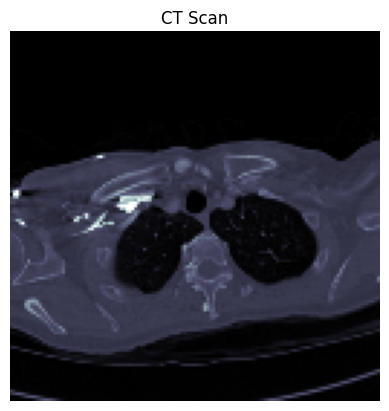


🫁 LUNG CANCER FULL ANALYSIS
Prediction Type     : BENIGN
Cancer Present      : NO
Malignancy Score    : 1
Estimated Stage     : No significant cancer
Risk Level          : LOW

 Class Breakdown:
Normal    : 0.00%
Benign    : 100.00%
Malignant : 0.00%
ℹ️ Monitor regularly (follow-up scan)


In [ ]:
sample_img = X_test[5]

predict_ct_scan(sample_img)

Please upload your DICOM (.dcm), JPG (.jpg/.jpeg), or PNG (.png) file(s).


Saving Screenshot 2026-04-27 at 15.18.41.png to Screenshot 2026-04-27 at 15.18.41.png
User uploaded file "Screenshot 2026-04-27 at 15.18.41.png"


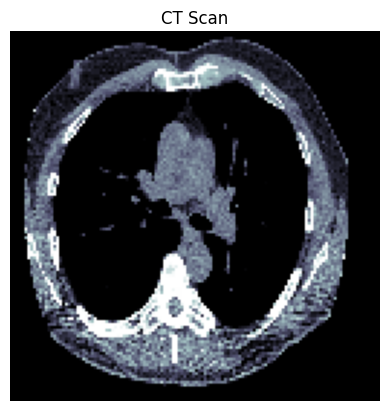


🫁 LUNG CANCER FULL ANALYSIS
Prediction Type     : MALIGNANT
Cancer Present      : YES
Malignancy Score    : 5
Estimated Stage     : Stage 4 (Advanced)
Risk Level          : VERY HIGH

 Class Breakdown:
Normal    : 0.00%
Benign    : 0.00%
Malignant : 100.00%
⚠️ Immediate medical consultation recommended


In [ ]:

from google.colab import files


# Helper function to read JPEG/PNG files and convert to grayscale if needed
def read_jpeg_png(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Error reading image: {path}")
        return None
    # Convert to grayscale if it's a color image, as our model expects single channel
    if len(img_bgr.shape) == 3 and img_bgr.shape[2] == 3:
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_bgr # Already grayscale
    return img_gray

print("Please upload your DICOM (.dcm), JPG (.jpg/.jpeg), or PNG (.png) file(s).")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')

    processed_img = None
    if fn.lower().endswith('.dcm'):
        # Save the uploaded file temporarily to read with pydicom
        with open(fn, 'wb') as f:
            f.write(uploaded[fn])
        raw = read_dicom(fn)
        if raw is not None:
            processed_img = preprocess_image(raw)
        os.remove(fn) # Clean up temporary file
    elif fn.lower().endswith(('.jpg', '.jpeg', '.png')):
        # Save the uploaded file temporarily to read with cv2
        with open(fn, 'wb') as f:
            f.write(uploaded[fn])
        raw = read_jpeg_png(fn)
        if raw is not None:
            processed_img = preprocess_image(raw)
        os.remove(fn) # Clean up temporary file
    else:
        print(f"Unsupported file type for {fn}. Skipping.")

    if processed_img is not None:
        predict_ct_scan(processed_img)
    else:
        print(f"Could not process image {fn}.")